完全に興味本位ですが、量子コンピューティングを使って解いてみたコードです！
（今回の問題の本来の想定解法・本筋ではないので、参考程度に流してください）

#### 結果
| ファイル | 距離 |
| ---- | ---- |
| `input_0` | 3291.621721409246 |
| `input_1` | 3778.715416492538 |
| `input_2` | 4494.417962262894 |
| `input_3` | 8444.466244537029 | 
| `input_4` | 15722.629767160775 |
| `input_5` | - |
| `input_6` | - |

#### 貪欲法などと比べて

##### メリット

    - 実装が直感的で簡単
    - (今回は実行時間に関して体感で変わるほど違いはなかった)

#### デメリット
    - 計算時間がO(N^3)で大きくなる
    - （無料版を使ったので、）Nが大きくなると対応できない

#### 参考
https://amplify.fixstars.com/ja/demo/tsp

In [1]:
!pip install amplify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 10.4 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install amplify matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 1.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 10.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 8.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 11.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 11.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 4.7 MB/s eta 0:00:00


In [ ]:
!pip install amplify numpy

In [177]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [178]:
import pandas as pd
df0 = pd.read_csv('/content/drive/MyDrive/Google関連/input_0.csv')
df1 = pd.read_csv('/content/drive/MyDrive/Google関連/input_1.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Google関連/input_2.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Google関連/input_3.csv')
df4 = pd.read_csv('/content/drive/MyDrive/Google関連/input_4.csv')
df5 = pd.read_csv('/content/drive/MyDrive/Google関連/input_5.csv')
df6 = pd.read_csv('/content/drive/MyDrive/Google関連/input_6.csv')

In [179]:
df0

,x,y
0,214.982791,762.690363
1,1222.039390,229.562123
2,792.696139,404.541958
3,1042.548756,709.851016
4,150.175339,25.512729


In [180]:
cities_0 = df0.values.tolist()
cities_1 = df1.values.tolist()
cities_2 = df2.values.tolist()
cities_3 = df3.values.tolist()
cities_4 = df4.values.tolist()
cities_5 = df5.values.tolist()
cities_6 = df6.values.tolist()

In [181]:
cities = cities_3

In [182]:
import matplotlib.pyplot as plt


def show_plot(locations):
    plt.figure(figsize=(7, 7))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.scatter(locations[:, 0], locations[:, 1])
    plt.show()

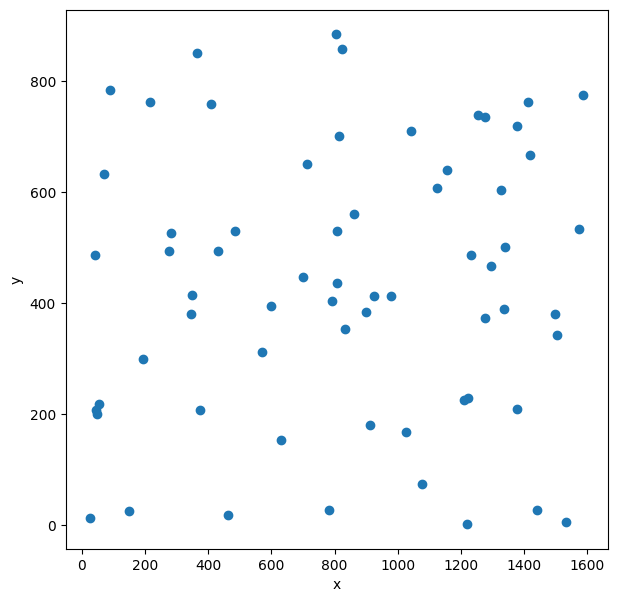

In [183]:
import numpy as np
show_plot(np.array(cities))

In [184]:
# 2点間のユーグリッド距離を求める関数
import math
def calurate_euclidean_distance(city1, city2):
    return math.sqrt((city1[0]-city2[0])**2 + (city1[1]-city2[1])**2)


# 各都市の距離を求める関数
def calcurate_distance(cities):
    num_cities = len(cities)
    # n×nの行列の初期化: i行j列はiからjへのユーグリッド距離を表す
    distance_matrix = [[0]*num_cities for _ in range(num_cities)]

    for i in range(num_cities):
        for j in range(i+1, num_cities):
            distance = calurate_euclidean_distance(cities[i], cities[j]) # ユーグリッド距離を求める
            distance_matrix[i][j] = distance_matrix[j][i] = distance # iからj、jからiの距離を記録
    return distance_matrix

In [185]:
distance = calcurate_distance(cities)
distances = np.array(distance)
print(distances)

[[   0.         1139.46861104  679.72273266 ... 1102.76146548
   772.87015283 1130.25940088]
 [1139.46861104    0.          463.63085521 ...  212.03491692
  1214.77504669   14.00765169]
 [ 679.72273266  463.63085521    0.         ...  435.28725791
   860.21282593  453.47095367]
 ...
 [1102.76146548  212.03491692  435.28725791 ...    0.
  1052.09366443  199.55092277]
 [ 772.87015283 1214.77504669  860.21282593 ... 1052.09366443
     0.         1201.00324679]
 [1130.25940088   14.00765169  453.47095367 ...  199.55092277
  1201.00324679    0.        ]]


In [186]:
from IPython.utils.sysinfo import num_cpus
from amplify import VariableGenerator

NUM_CITIES = len(np.array(cities))
gen = VariableGenerator()
q = gen.array("Binary", shape=(NUM_CITIES + 1, NUM_CITIES))
q[NUM_CITIES, :] = q[0, :] ##最初と最後を同じに

print(q)

[[  q_{0,0},   q_{0,1},   q_{0,2}, ...,  q_{0,61},  q_{0,62},  q_{0,63}],
 [  q_{1,0},   q_{1,1},   q_{1,2}, ...,  q_{1,61},  q_{1,62},  q_{1,63}],
 [  q_{2,0},   q_{2,1},   q_{2,2}, ...,  q_{2,61},  q_{2,62},  q_{2,63}],
 ..., 
 [ q_{62,0},  q_{62,1},  q_{62,2}, ..., q_{62,61}, q_{62,62}, q_{62,63}],
 [ q_{63,0},  q_{63,1},  q_{63,2}, ..., q_{63,61}, q_{63,62}, q_{63,63}],
 [  q_{0,0},   q_{0,1},   q_{0,2}, ...,  q_{0,61},  q_{0,62},  q_{0,63}]]


In [ ]:
from amplify import sum

#目的関数　Σを表現していく
arr =[]
for n in range(NUM_CITIES):
    for i in range(NUM_CITIES):
        for j in range(NUM_CITIES):
            arr.append(distances[i,j] * q[n, i]* q[n+1, j])
obj = sum(arr)
print(obj)

In [ ]:
#制約条件　one hot 関数を使うver
from amplify import one_hot

# 最後の行を除いた q の各行のうち一つのみが 1 である制約
row_constraints = one_hot(q[:-1], axis=1)

# 最後の行を除いた q の各列のうち一つのみが 1 である制約
col_constraints = one_hot(q[:-1], axis=0)

constraints = row_constraints + col_constraints

In [ ]:
from amplify import one_hot
#わかりやすい例
one_hot(q[0])

In [ ]:
#ここまでが数式をプログラムで表す作業
alpha = np.amax(distances)

model = obj + alpha * constraints

In [ ]:
#modelを量子コンピュータに入れる
from datetime import timedelta
from amplify import FixstarsClient, solve
from datetime import timedelta


client = FixstarsClient()
client.token = "YOUR_API"  # ローカル環境等で使用する場合は、Amplify AE のアクセストークンを入力してください。
client.parameters.timeout = timedelta(milliseconds=1000)  # タイムアウト 1000 ミリ秒

# ソルバーの設定と結果の取得
result = solve(model, client) #resultにけっかが格納されている
if len(result) == 0:
    raise RuntimeError("At least one of the constraints is not satisfied.")

In [ ]:
result.best.objective

In [ ]:
q_values = q.evaluate(result.best.values)
q_values

In [ ]:
route = np.where(np.array(q_values) == 1)[1]
print(route)

In [ ]:
def show_route(route: np.ndarray, distances: np.ndarray, locations: np.ndarray):
    path_length = sum([distances[route[i]][route[i + 1]] for i in range(NUM_CITIES)])

    x = [i[0] for i in locations]
    y = [i[1] for i in locations]
    plt.figure(figsize=(7, 7))
    plt.title(f"path length: {path_length}")
    plt.xlabel("x")
    plt.ylabel("y")

    for i in range(NUM_CITIES):
        r = route[i]
        n = route[i + 1]
        plt.plot([x[r], x[n]], [y[r], y[n]], "b-")
    plt.plot(x, y, "ro")
    plt.show()

    return path_length

In [ ]:
show_route(route, distances, cities)